In [39]:
import matplotlib.pyplot as plt

In [40]:
%matplotlib inline
import re
import numpy as np
import pandas as pd

In [41]:
import matplotlib.pyplot as plt

In [42]:
import seaborn as sns

In [43]:
import plotly.offline as py

In [44]:
import plotly.graph_objs as go

In [45]:
import plotly.tools as tls

In [46]:
from bs4 import BeautifulSoup

In [47]:
from sklearn.model_selection import cross_validate

In [48]:
from sklearn.model_selection import StratifiedKFold

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
from sklearn.ensemble import ExtraTreesClassifier

In [51]:
from sklearn.decomposition import TruncatedSVD

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [53]:
from sklearn.pipeline import Pipeline

In [54]:
from sklearn.naive_bayes import MultinomialNB

In [55]:
from sklearn.model_selection import learning_curve

In [56]:
py.init_notebook_mode(connected = True)

In [57]:
train = pd.read_csv('mbti_posts.csv')

In [58]:
us = pd.read_csv('users.csv')

In [59]:
ps = pd.read_csv('forum_messages.csv')

In [60]:
mbti = {'I':'Introversion', 'E':'Extroversion', 'N':'Intutions', 'S':'Sensing', 'T':'Thinking',
        'F':'Feeling', 'J':'Judging', 'P' : 'Perceiving'}

In [61]:
train.shape

(8675, 2)

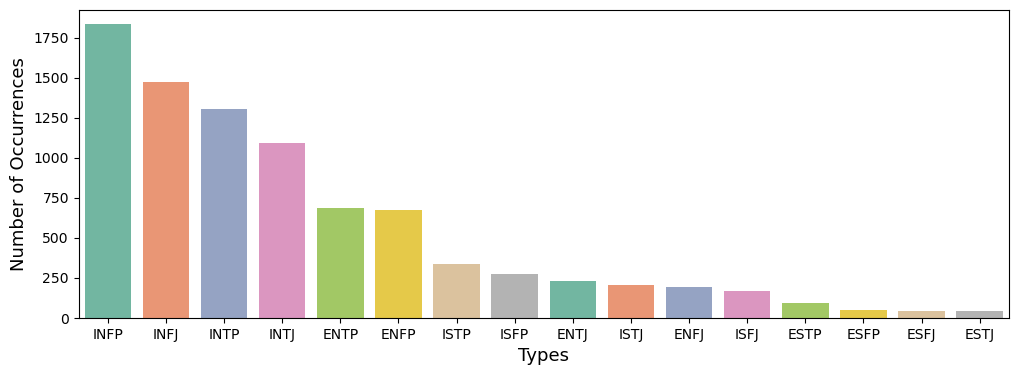

In [62]:
cnt_srs = train['type'].value_counts()

plt.figure(figsize=(12,4))
sns.barplot(
    x=cnt_srs.index,
    y=cnt_srs.values,
    hue=cnt_srs.index,      
    palette="Set2",
    legend=False
)

plt.ylabel('Number of Occurrences', fontsize=13)
plt.xlabel('Types', fontsize=13)
plt.show()

In [63]:
ps['message'] = ps['message'].fillna('')

In [64]:
ps_join=ps.groupby('user_id')['message'].agg(lambda col:' '.join(col)).reset_index()

In [65]:
from sklearn.ensemble import ExtraTreesClassifier

etc = ExtraTreesClassifier(n_estimators=20, max_depth = 4, n_jobs = -1)
tfidf = TfidfVectorizer(ngram_range=(1,1),stop_words = 'english')
tsvd = TruncatedSVD(n_components = 10)
model = Pipeline([('tfidf',tfidf),('tsvd1',tsvd),('etc',etc)])

In [66]:
kfolds = StratifiedKFold(n_splits = 5, shuffle = True, random_state=1)

In [67]:
np.random.seed(1)
scoring = {'acc':'accuracy',
           'neg_log_loss':'neg_log_loss',
           'f1_micro':'f1_micro'}

results = cross_validate(model, train['posts'], train['type'], cv=kfolds,
                         scoring = scoring, n_jobs=-1)

In [68]:
print("CV Accuracy:{:0.4f}(+/- {:0.4f})".format(np.mean(results['test_acc']),
                                                np.std(results['test_acc'])))
print("CV F1 :{:0.4f}(+/- {:0.4f})".format(np.mean(results['test_f1_micro']),
                                                np.std(results['test_f1_micro'])))
print("CV Logloss:{:0.4f}(+/- {:0.4f})".format(np.mean(results['test_neg_log_loss']),
                                                np.std(results['test_neg_log_loss'])))

CV Accuracy:0.2951(+/- 0.0188)
CV F1 :0.2951(+/- 0.0188)
CV Logloss:-2.1456(+/- 0.0180)


In [69]:
def cleanText(text):
    text = BeautifulSoup(text,'lxml').text
    text = re.sub(r'\|\|\|',r'',text)
    text = re.sub(r'http\S+',r'<URL>', text)
    return text

In [73]:
train ['clean_posts'] = train['posts'].apply(cleanText)

In [74]:
np.random.seed(1)

tfidf2 = CountVectorizer(ngram_range=(1,1),
                         stop_words = 'english',
                         lowercase = True,
                         max_features = 5000)

model_lr = Pipeline([('tfidf1', tfidf2), ('lr', MultinomialNB())])

results_lr = cross_validate(model_lr, train['clean_posts'], train['type'], cv=kfolds,
                            scoring=scoring, n_jobs=-1)

In [75]:
print("CV Accuracy:{:0.4f}(+/- {:0.4f})".format(np.mean(results_lr['test_acc']),
                                                np.std(results_lr['test_acc'])))

print("CV F1 :{:0.4f}(+/- {:0.4f})".format(np.mean(results_lr['test_f1_micro']),
                                                np.std(results_lr['test_f1_micro'])))

print("CV Logloss:{:0.4f}(+/- {:0.4f})".format(np.mean(-1*results_lr['test_neg_log_loss']),
                                                np.std(-1*results_lr['test_neg_log_loss'])))

CV Accuracy:0.5637(+/- 0.0121)
CV F1 :0.5637(+/- 0.0121)
CV Logloss:6.2047(+/- 0.3709)


In [76]:
train_sizes, train_scores, test_scores = \
        learning_curve(model_lr, train['clean_posts'], train['type'], cv = kfolds, n_jobs = -1,
                       scoring = 'f1_micro', train_sizes = np.linspace(.1,1.0,10), random_state = 1)

In [77]:
def plot_learning_curve(X, y, train_sizes, train_scores, test_scores,
                        title='', ylim=None, figsize=(14, 8)):

    plt.figure(figsize=figsize)
    plt.title(title)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)

    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r"
    )

    plt.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g"
    )

    plt.plot(
        train_sizes,
        train_scores_mean,
        'o-',
        color="r",
        label="Training score"
    )

    plt.plot(
        train_sizes,
        test_scores_mean,
        'o-',
        color="g",
        label="Cross-validation score"
    )

    plt.legend(loc="best")
    return plt

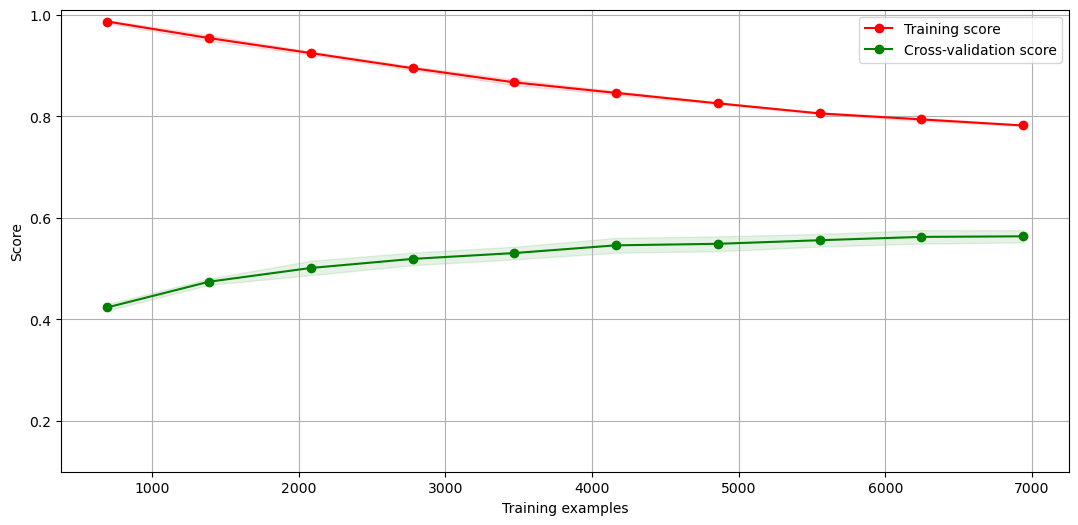

In [78]:
plot_learning_curve(train['posts'],train['type'],train_sizes,
                    train_scores,test_scores,ylim=(0.1,1.01),figsize=(13,6))

plt.show()

In [79]:
ps_join['clean_comments']=ps_join['message'].apply(cleanText)

In [80]:
model_lr.fit(train['clean_posts'],train['type'])
pred_all=model_lr.predict(ps_join['clean_comments'])

In [86]:
pred_df = pd.DataFrame(pred_all, columns=['personality'])

pred_df = (
    pred_df['personality']
    .value_counts()
    .reset_index()
)

pred_df.columns = ['personality', 'count']

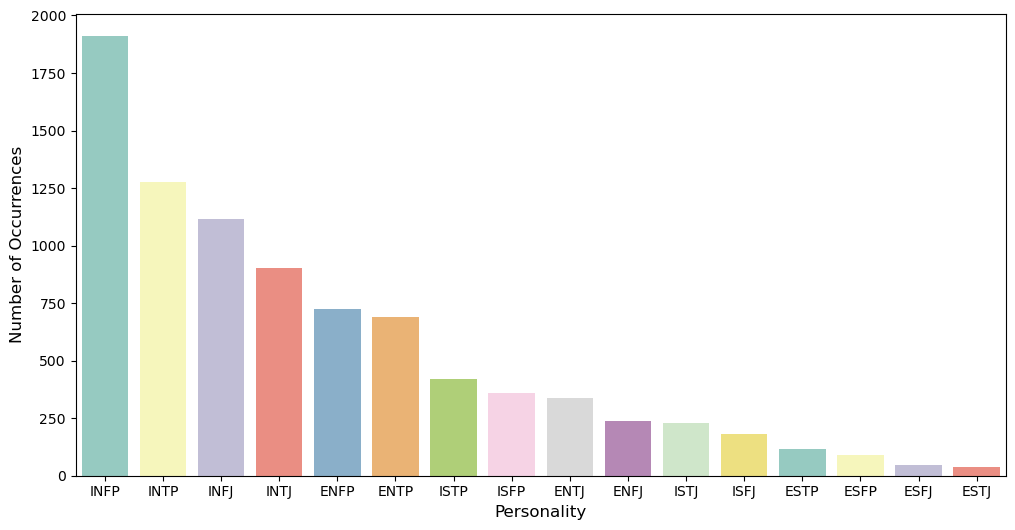

In [87]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=pred_df,
    x='personality',
    y='count',
    hue='personality',
    palette='Set3',
    legend=False
)

plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Personality', fontsize=12)
plt.show()

In [88]:
pred_df['percent']=pred_df['count']/pred_df['count'].sum()

In [89]:
pred_df['descroption']=pred_df['personality'].apply(lambda x: " ".join([mbti[l] for l in list(x)]))

In [90]:
pred_df

,personality,count,percent,descroption
0,INFP,1912,0.220403,Introversion Intutions Feeling Perceiving
1,INTP,1278,0.147320,Introversion Intutions Thinking Perceiving
2,INFJ,1115,0.128530,Introversion Intutions Feeling Judging
3,INTJ,901,0.103862,Introversion Intutions Thinking Judging
4,ENFP,725,0.083573,Extroversion Intutions Feeling Perceiving
5,ENTP,690,0.079539,Extroversion Intutions Thinking Perceiving
6,ISTP,422,0.048646,Introversion Sensing Thinking Perceiving
7,ISFP,360,0.041499,Introversion Sensing Feeling Perceiving
8,ENTJ,337,0.038847,Extroversion Intutions Thinking Judging
9,ENFJ,237,0.027320,Extroversion Intutions Feeling Judging


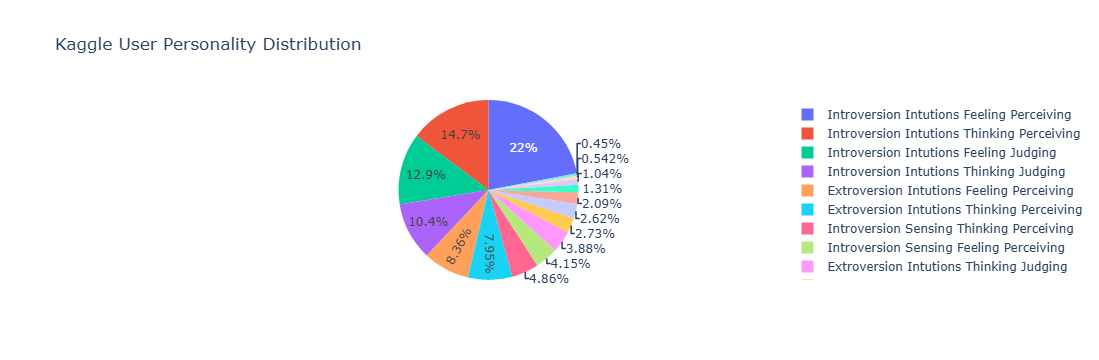

In [91]:
labels = pred_df['descroption']
sizes = pred_df['percent']*100

trace = go.Pie(labels = labels, values = sizes)
layout = go.Layout(
    title = 'Kaggle User Personality Distribution')

data = [trace]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig)